[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FM4CS/thor_terratorch_ext/blob/main/notebooks/thor_embedding_generation_sen1floods11.ipynb)

### Setup for Google Colab

If you are running this notebook in Google Colab, complete the following steps:

1. In Colab, we recommend going to **Runtime → Change runtime type** and selecting **T4 GPU**
2. Install the **TerraTorch THOR** extension and the required packages
3. Download the dataset (as part of the notebook)

In [9]:
import os

IN_COLAB = bool(os.getenv("COLAB_RELEASE_TAG"))
if IN_COLAB:
    !git clone https://github.com/fm4cs/thor_terratorch_ext.git
    %cd thor_terratorch_ext
    %pip install -e .
    %pip install tensorboard

------------

## Notebook: Embedding Generation with THOR in TerraTorch (Sen1Floods11)

This notebook shows how to generate dense spatial embeddings from Sentinel-2 imagery using the THOR foundation model via TerraTorch's `EmbeddingGenerationTask`. We use the Sen1Floods11 dataset as input, visualize the raw embeddings with PCA, and explore the spatial structure of the learned representations.

## Data Download

In [10]:
import gdown
from pathlib import Path


dataset_path = Path("../sen1floods11_v1.1")
archive_path = dataset_path.with_suffix(".tar.gz")

# Extract archive if dataset directory does not exist
if not dataset_path.exists():
    # Download archive if it does not exist
    if not archive_path.is_file():
        gdown.download(
            "https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS",
            str(archive_path),
            quiet=False,
        )
    !tar -xzf {archive_path} -C {dataset_path.parent}
!ls "{dataset_path}/data"

CopernicusDEM  JRCWaterHand  LabelHand	S1GRDHand  S1OtsuLabelHand  S2L1CHand


## Run Embedding Generation via TerraTorch CLI

We run `terratorch predict` using the provided config, which runs the THOR backbone over all prediction samples and saves the output embeddings as GeoTIFF files. The config specifies the model backbone, the input data, and the output directory.

In [11]:
!cd .. && terratorch predict -c ./config/embedding_generation_sen1floods11_S2.yaml

Seed set to 0
/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-03-17 13:22:18,784 - INFO - Patching timm Attention and Block to use Alibi...
2026-03-17 13:22:18,784 - INFO - Using normal attention for timm Attention
2026-03-17 13:22:18,871 - INFO - Found thor_terratorch_ext
2026-03-17 13:22:18,980 - INFO - GeoTIFF selected; 2D token embeddings (ViT) will be reshaped to [C, sqrt(num_tokens), sqrt(num_tokens)] 

## Load and Explore Embeddings

Each embedding file is a GeoTIFF with shape `(C, H, W)` where `C=1536` (2 sensor groups × 768 dimensions, concat-merged) and `H=W=18` spatial patches (for a 288×288 input at `patch_size=16`). We load one embedding and inspect its shape.

In [14]:
import rasterio
import numpy as np
from pathlib import Path

embed_dir = Path("../output/thor_embeddings/layer_00")
embed_files = sorted(embed_dir.glob("*_embedding.tif"))
print(f"Found {len(embed_files)} embedding files")


# Load a few embeddings
def load_embedding(path):
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)  # (C, H, W)


sample_path = embed_files[1]
emb = load_embedding(sample_path)
print(f"Embedding shape: {emb.shape}  (channels, height, width)")
print(f"Sample: {sample_path.name}")

Found 1250 embedding files
Embedding shape: (1536, 36, 36)  (channels, height, width)
Sample: Bolivia_129334_S2Hand_embedding.tif


## Corresponding Input Image

We load and show the RGB input image corresponding to the first embedding. The input images are 13-band Sentinel-2 L1C GeoTIFFs; we read bands B04 (Red), B03 (Green), and B02 (Blue) for visualization.

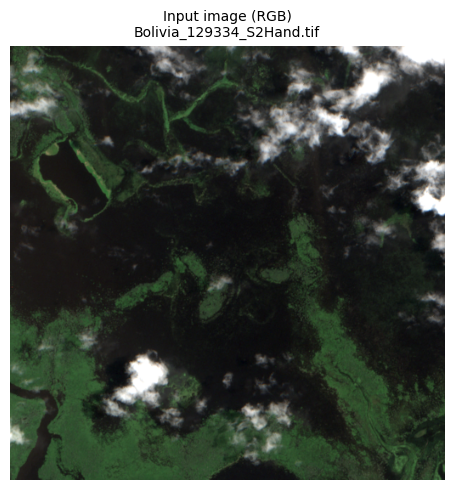

In [15]:
import matplotlib.pyplot as plt
from terratorch.datasets.utils import to_rgb

# Load the corresponding input image
img_name = sample_path.name.replace("_embedding.tif", ".tif")
img_path = dataset_path / "data/S2L1CHand" / img_name

with rasterio.open(img_path) as src:
    # Read bands B04 (Red), B03 (Green), B02 (Blue) = indices 3, 2, 1 (0-based)
    rgb = src.read([4, 3, 2]).astype(np.float32)  # (3, H, W)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(to_rgb(rgb, [0, 1, 2]))
ax.set_title(f"Input image (RGB)\n{img_name}", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

## PCA Visualization of the Embedding

Since the embedding has 1536 channels, we use PCA to reduce it to 3 components, which we display as an RGB image. This gives an intuitive view of the spatial structure learned by the THOR backbone — similar features in the scene will appear in similar colors.

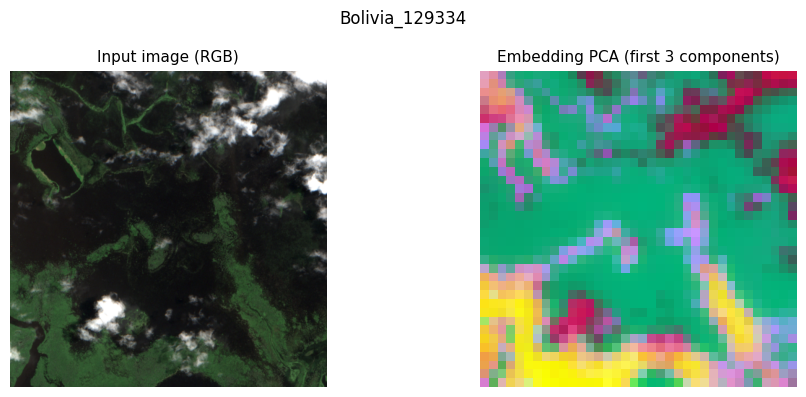

In [16]:
import numpy as np
from terratorch.datasets.utils import to_pca_rgb, to_rgb

pca_rgb, _, _ = to_pca_rgb(emb, step=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(to_rgb(rgb, [0, 1, 2]))
axes[0].set_title("Input image (RGB)", fontsize=11)
axes[0].axis("off")

axes[1].imshow(pca_rgb)
axes[1].set_title("Embedding PCA (first 3 components)", fontsize=11)
axes[1].axis("off")

plt.suptitle(img_name.replace("_S2Hand.tif", ""), fontsize=12)
plt.tight_layout()
plt.show()

## PCA Across Multiple Embeddings

Fitting PCA on patches from multiple images gives a consistent color space across images, making it easier to compare embeddings. We load a sample of embeddings, fit a single global PCA, and apply it to each one.

/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Explained variance by first 3 PCs: 68.9%


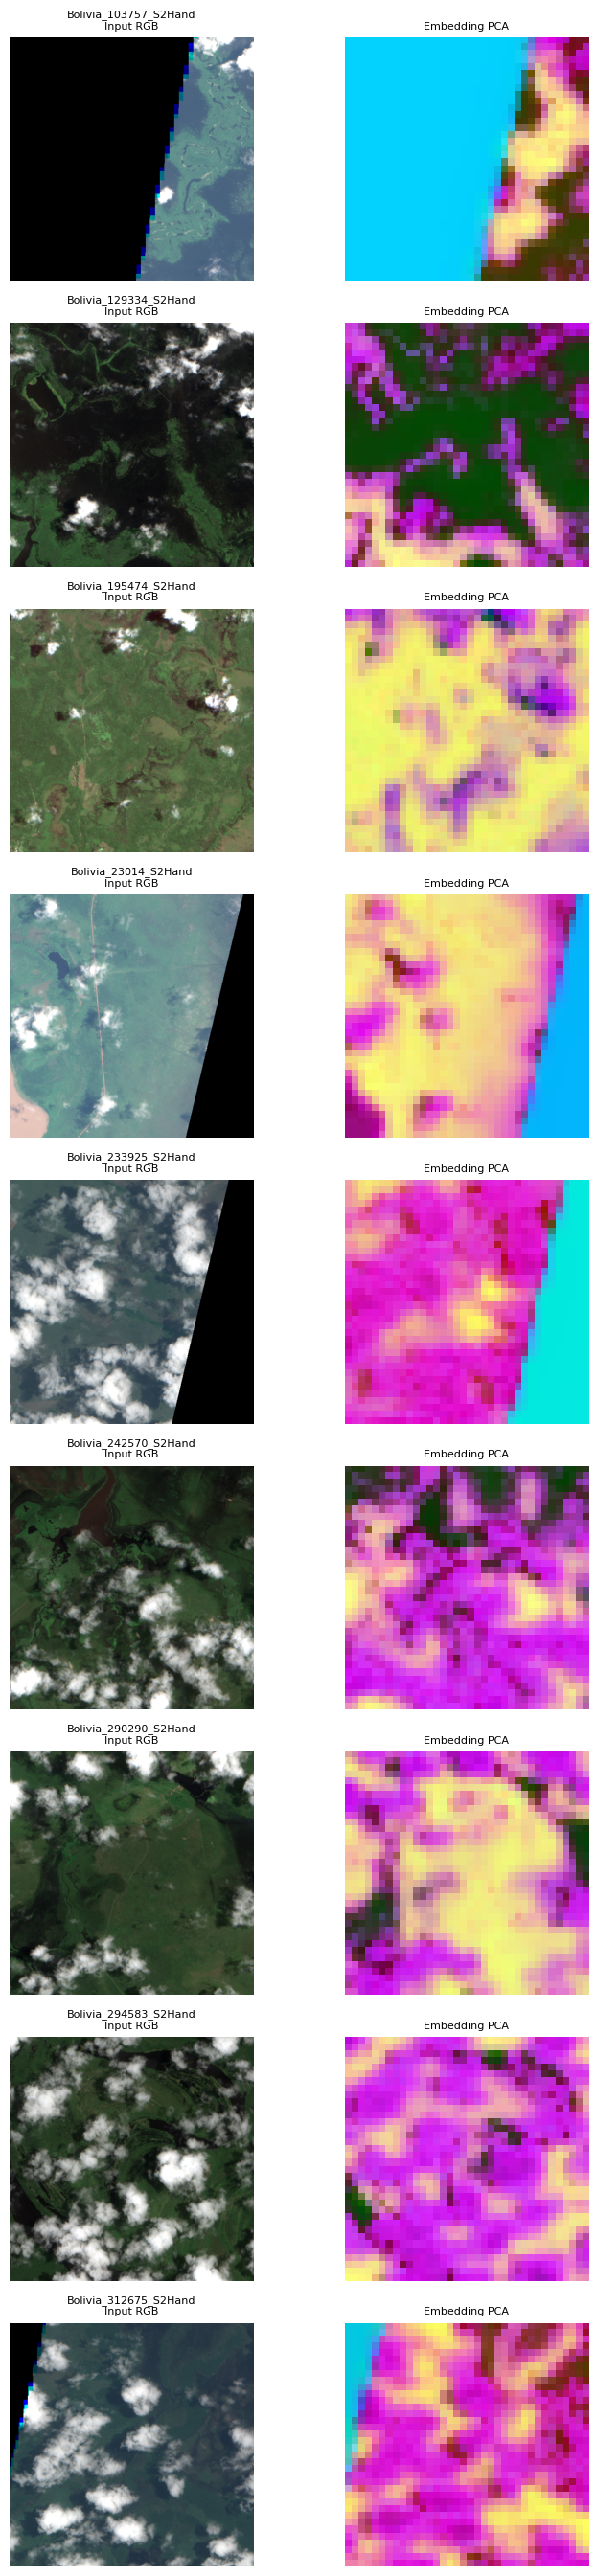

In [17]:
from sklearn.decomposition import PCA
from terratorch.datasets.utils import to_rgb

# Load a sample of embeddings for a joint PCA
n_samples = min(9, len(embed_files))
sample_files = embed_files[:n_samples]

embeddings = [load_embedding(f) for f in sample_files]
C, H, W = embeddings[0].shape

# Stack all patches and fit PCA globally
all_patches = np.concatenate(
    [e.reshape(C, H * W).T for e in embeddings], axis=0
)  # (N*H*W, C)
pca_global = PCA(n_components=3)
pca_global.fit(all_patches)
print(
    f"Explained variance by first 3 PCs: {pca_global.explained_variance_ratio_.sum():.1%}"
)


def apply_global_pca(emb, pca):
    C, H, W = emb.shape
    patches = emb.reshape(C, H * W).T
    reduced = pca.transform(patches).reshape(H, W, 3)
    for c in range(3):
        mn, mx = reduced[..., c].min(), reduced[..., c].max()
        reduced[..., c] = (reduced[..., c] - mn) / (mx - mn + 1e-8)
    return reduced


def load_rgb(embed_path):
    img_name = embed_path.name.replace("_embedding.tif", ".tif")
    img_path = dataset_path / "data/S2L1CHand" / img_name
    with rasterio.open(img_path) as src:
        rgb = src.read([4, 3, 2]).astype(np.float32)
    return to_rgb(rgb, [0, 1, 2])


fig, axes = plt.subplots(n_samples, 2, figsize=(8, n_samples * 3))
for i, (f, emb) in enumerate(zip(sample_files, embeddings)):
    name = f.stem.replace("_embedding", "")
    axes[i, 0].imshow(load_rgb(f))
    axes[i, 0].set_title(f"{name}\nInput RGB", fontsize=8)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(apply_global_pca(emb, pca_global))
    axes[i, 1].set_title("Embedding PCA", fontsize=8)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Individual Embedding Channels

To understand what individual channels capture, we plot a selection of raw embedding channels as heatmaps. Different channels respond to different spatial features — some may highlight water bodies, vegetation edges, or built-up areas.

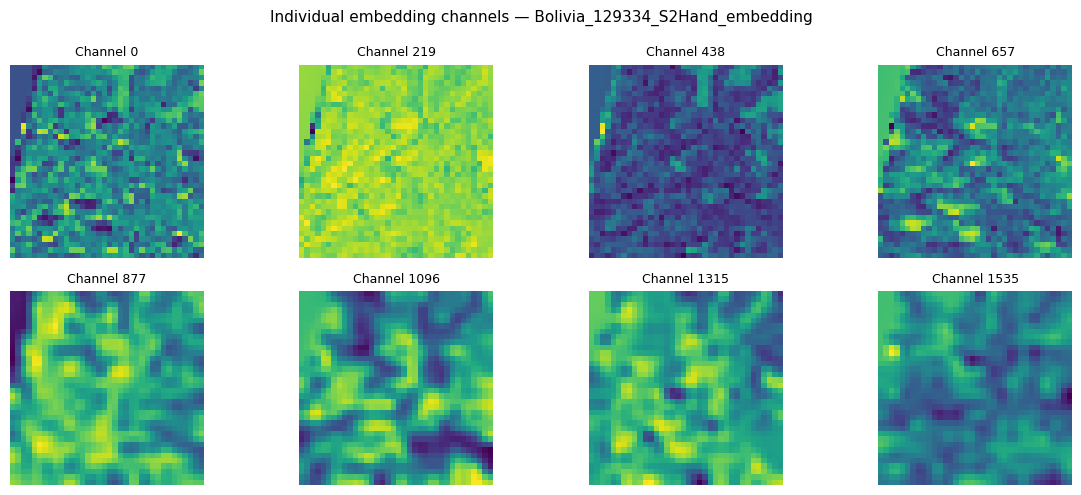

In [18]:
n_channels_to_show = 8
channel_indices = np.linspace(0, C - 1, n_channels_to_show, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for ax, ch in zip(axes.flat, channel_indices):
    ax.imshow(emb[ch], cmap="viridis")
    ax.set_title(f"Channel {ch}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Individual embedding channels — {sample_path.stem}", fontsize=11)
plt.tight_layout()
plt.show()

## Summary

In this notebook, we ran THOR embedding generation via the TerraTorch CLI (`terratorch predict`) and visualized the resulting dense spatial embeddings using PCA and per-channel heatmaps. The embeddings capture rich spatial representations that can be used as features for downstream tasks such as change detection, clustering, or linear probing — without any task-specific fine-tuning.